In [1]:
# Task 1

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import shap

# Load the Titanic data
titanic = pd.read_csv("titanic_survival.csv")

titanic["age"] = titanic["age"].fillna(titanic["age"].median())

# The random forest uses five columns, same as the ensemble unit
rf_features = ["pclass", "age", "fare", "sibsp", "parch"]
X_rf = titanic[rf_features]
y = titanic["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# The logistic regression uses two columns, same as the
# classification unit
log_features = ["pclass", "fare"]
X_log = titanic[log_features]

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_log, y_train_log)

print("Random forest test accuracy:", rf_model.score(X_test, y_test))
print("Logistic regression test accuracy:",
      log_model.score(X_test_log, y_test_log))

Random forest test accuracy: 0.7262569832402235
Logistic regression test accuracy: 0.7039106145251397


In [2]:
# Task 2

coalition_values = {
    (): 0,
    ("A",): 10,
    ("B",): 4,
    ("C",): 6,
    ("A", "B"): 18,
    ("A", "C"): 19,
    ("B", "C"): 13,
    ("A", "B", "C"): 24,
}

def marginal(worker, before_group):
    after_group = tuple(sorted(before_group + (worker,)))
    before_group = tuple(sorted(before_group))
    return coalition_values[after_group] - coalition_values[before_group]

def average(values):
    return sum(values) / len(values)

A_contributions = [
    marginal("A", ()),
    marginal("A", ("B",)),
    marginal("A", ("C",)),
    marginal("A", ("B", "C")),
]

B_contributions = [
    marginal("B", ()),
    marginal("B", ("A",)),
    marginal("B", ("C",)),
    marginal("B", ("A", "C")),
]

C_contributions = [
    marginal("C", ()),
    marginal("C", ("A",)),
    marginal("C", ("B",)),
    marginal("C", ("A", "B")),
]

weights = [2, 1, 1, 2]

A_shapley = sum(c * w for c, w in zip(A_contributions, weights)) / 6
B_shapley = sum(c * w for c, w in zip(B_contributions, weights)) / 6
C_shapley = sum(c * w for c, w in zip(C_contributions, weights)) / 6

print(f"A Shapley: {A_shapley:.2f}")
print(f"B Shapley: {B_shapley:.2f}")
print(f"C Shapley: {C_shapley:.2f}")
print(f"Sum of values: {A_shapley + B_shapley + C_shapley}")

A Shapley: 11.50
B Shapley: 5.50
C Shapley: 7.00
Sum of values: 24.0


In [3]:
# Task 3

# Build explainer
explainer = shap.TreeExplainer(rf_model)
# Compute SHAP values for every row in the test set
shap_values = explainer(X_test)

print(shap_values.values.shape)

values = shap_values.values[0, :, 1]

for feature, value in zip(rf_features, values):
    print(f"{feature}: {value:.2f}")

(179, 5, 2)
pclass: -0.11
age: -0.05
fare: 0.03
sibsp: 0.03
parch: 0.04


In [4]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
X_test.head()

,pclass,age,fare,sibsp,parch
709,3,28.0,15.2458,1,1
439,2,31.0,10.5000,0,0
840,3,20.0,7.9250,0,0
720,2,6.0,33.0000,0,1
39,3,14.0,11.2417,1,0


In [6]:
y_test.head()

709    1
439    0
840    0
720    1
39     1
Name: survived, dtype: int64

In [7]:
shap_values

.values =
array([[[ 0.11386786, -0.11386786],
        [ 0.04714031, -0.04714031],
        [-0.03227196,  0.03227196],
        [-0.03389958,  0.03389958],
        [-0.04029967,  0.04029967]],

       [[ 0.05392565, -0.05392565],
        [ 0.06459769, -0.06459769],
        [ 0.08899735, -0.08899735],
        [ 0.00241232, -0.00241232],
        [ 0.04517935, -0.04517935]],

       [[ 0.06958461, -0.06958461],
        [ 0.0956282 , -0.0956282 ],
        [ 0.03199661, -0.03199661],
        [ 0.01285034, -0.01285034],
        [ 0.01255259, -0.01255259]],

       ...,

       [[ 0.13166991, -0.13166991],
        [ 0.09542809, -0.09542809],
        [ 0.07079875, -0.07079875],
        [ 0.0027778 , -0.0027778 ],
        [ 0.06443782, -0.06443782]],

       [[-0.02953966,  0.02953966],
        [ 0.02256879, -0.02256879],
        [ 0.06696317, -0.06696317],
        [ 0.00691308, -0.00691308],
        [ 0.05320697, -0.05320697]],

       [[ 0.06626978, -0.06626978],
        [-0.33928449,  0.339284

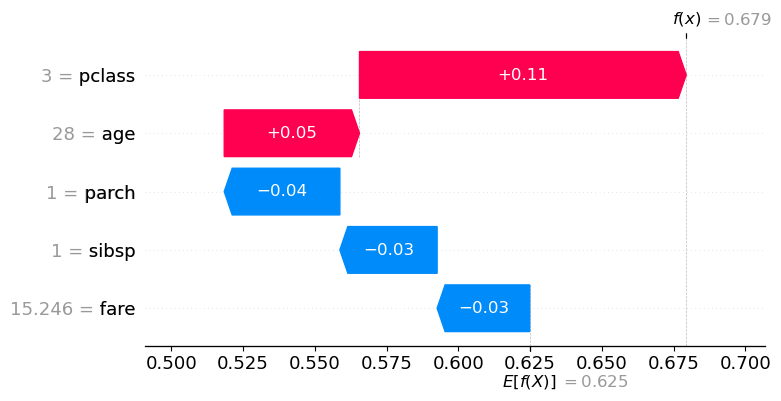

In [8]:
# Task 4

#row =0
shap.plots.waterfall(shap_values[0, :, 0])

This passenger prediction was pushed down by parch (parent/child), sibsp (siblings), and fare. These values decreased the predicted chance of not surviving (towards survival). Pclass of 3 and age of 28 pushed up the predicted chance of not surviving. Overall there was a 68% chance the passenger would not survive. 

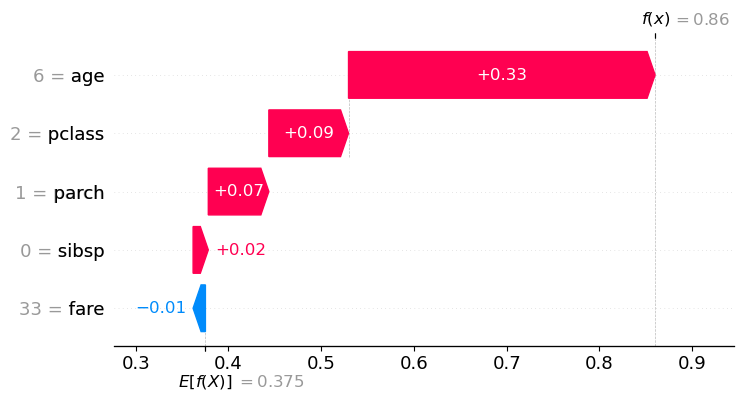

In [9]:
#row = 1
shap.plots.waterfall(shap_values[3, :, 1])

For the row 3 passenger (survived), the predicted chance of survival was pushed up by age (6), pclass(2), and parch (parent/child1). This passenger had a 86% chance of survival. 

The values were fairly consistent with our expectations based on dataset knowledge. 

In [10]:
base_value = explainer.expected_value[1]

In [11]:
## Task 5 Check the Books Balance

shap_sum = shap_values.values[3, :, 1].sum()
total= shap_sum + base_value
real_prediction = rf_model.predict_proba(X_test)[3][1]

print("SHAP sum + base value:", total)
print("Real predicted probability:", real_prediction)




SHAP sum + base value: 0.8600000000000019
Real predicted probability: 0.86


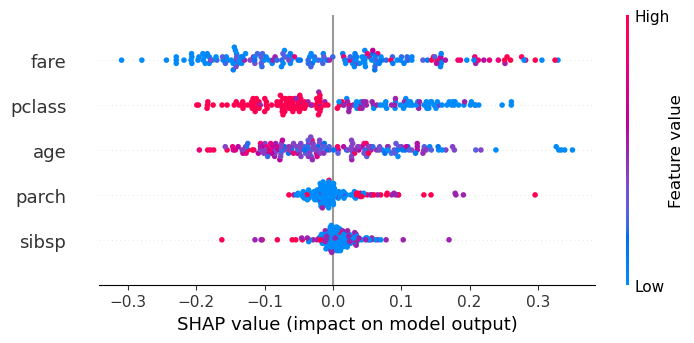

In [12]:
## Task 6 Zoom out to the whole dataset

shap.plots.beeswarm(shap_values[:, :, 1])

In [13]:
rf_model.feature_importances_

array([0.08208659, 0.37910872, 0.42740896, 0.06221001, 0.04918572])

In [14]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=rf_features
).sort_values(ascending=False)

print(rf_importance)

fare      0.427409
age       0.379109
pclass    0.082087
sibsp     0.062210
parch     0.049186
dtype: float64


The order is not the same for shap and feature importance. A feature might only have a large effect on a small number of passengers. Shap is looking at one prediction while feature importance measures the model. 

### Task 7

- A single coefficient measures overall impact on predictions, while a SHAP value gives the exact impact that feature had on a particular prediction.

In [ ]:
#from sklearn.linear_model import LogisticRegression

#model = LogisticRegression()


masker = shap.maskers.Independent(X_train_log, max_samples=len(X_train_log))
log_explainer = shap.LinearExplainer(log_model, masker)
log_shap_values = explainer(X_test_log)


row = 0

# Reading fare's SHAP value directly
fare_shap_value = log_shap_values.values[row][1]

# Calculating the same number by hand
fare_coefficient = log_model.coef_[0][1]
average_fare = X_train_log["fare"].mean()
this_fare = X_test_log["fare"].iloc[row]
fare_by_hand = fare_coefficient * (this_fare - average_fare)

print("SHAP value for fare:", fare_shap_value)
print("Calculated by hand:", fare_by_hand)


### Advanced:

- Come back to values for same passengers

In [23]:
# A small random sample keeps KernelExplainer fast
import numpy as np
import time
start_kernal = time.time()
background = shap.sample(X_train, 10, random_state=42)
kernel_explainer = shap.KernelExplainer(
    rf_model.predict_proba, background
)
kernel_shap_values = kernel_explainer.shap_values(X_test.iloc[:30])
time_kernal = time.time() - start_kernal

start_tree = time.time()
shap_values = explainer(X_test)
values = shap_values.values[0, :, 1]
time_tree = time.time() - start_tree

print(np.array(kernel_shap_values).shape)
print(f'Kernal Time: {time_kernal}')
print(f'Kernal Values: {kernel_shap_values[0, :, 1]}')

print(f'Tree Time: {time_tree}')
print(f'Tree Values: {shap_values.values[0, :, 1]}')

  0%|          | 0/30 [00:00<?, ?it/s]

(30, 5, 2)
Kernal Time: 1.181663990020752
Kernal Values: [-0.15976522 -0.04592197 -0.01273828  0.008443    0.03065365]
Tree Time: 0.6702244281768799
Tree Values: [-0.11386786 -0.04714031  0.03227196  0.03389958  0.04029967]


### Advanced 2:

- As fare increases, pclass decreases. This makes it hard to tell which of the two may deserve credit for a prediction, as they generally have a linear relationship with each other. If there is some nuance between their relationship, it could be possible to explain with additional features, however, on their own it is hard to decouple.

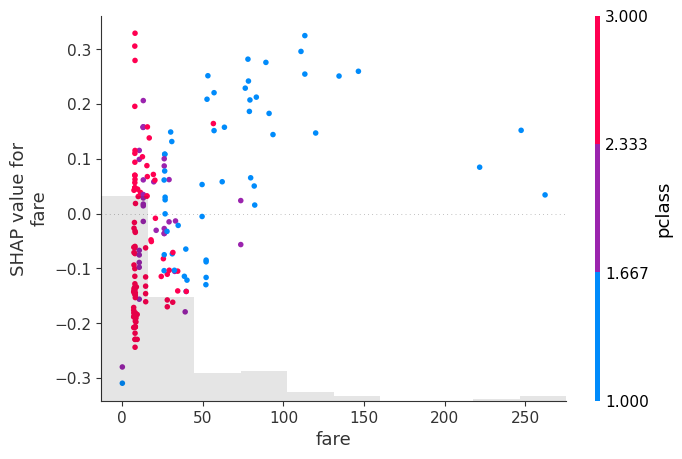

In [24]:
sv_class1 = shap_values[:, :, 1]

shap.plots.scatter(
    sv_class1[:, "fare"],
    color=sv_class1[:, "pclass"]
)

### Extra Credit:

- The model rated fare the highest at 0.427409
- Our indiviudal rated age the highest, with fare being negligible

- This is a prime example of why the model can, overall, care about one particular feature, despite having individual disagreements. In our model overall, Fare is weighted highly, as it has a strong relationship with cabin placement and which class of passenger you belong to, with high class passengers being more likely to survive. However, in our individual example, we have a passenger whose fare had very little to do with their survival. This is because this passenger was six years old, and got priority for evacuation, making them more likely to survive.

- This is a good example of how SHAP struggles with the relationship between correlation and causation. While it can explain exactly what your model thought was important to your predictions, it cannot tangibly understand *why* it was important. And while certain models do better jobs at explaining complex relationships, they can only ever understand them in the context of the data provided.

Row Number: 3
pclass: 0.09
age: 0.33
fare: -0.01
sibsp: 0.02
parch: 0.07


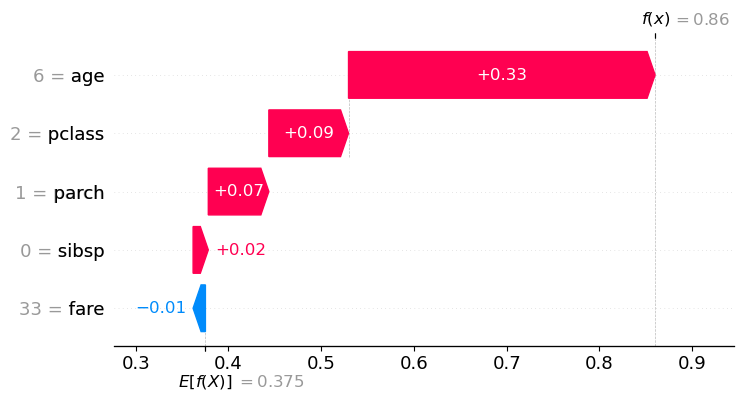

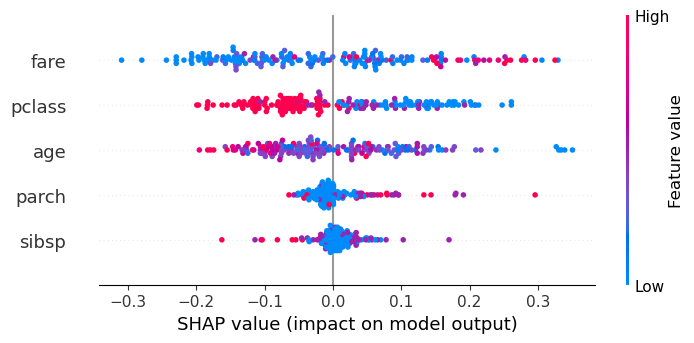

In [29]:
import random
#random_row = random.randint(0, 5)
random_row = 3
test_values = shap_values.values[random_row, :, 1]
print(f'Row Number: {random_row}')
for feature, value in zip(rf_features, test_values):
    print(f"{feature}: {value:.2f}")
    
shap.plots.waterfall(shap_values[random_row, :, 1])
shap.plots.beeswarm(shap_values[:, :, 1])